# Poland Macroeconomic Time Series Analysis

## Reference Paper: 
This project is based on the following academic study: 
"Interactions between Output, Inflation, Interest Rates and House Prices: International Evidence".

We reproduce the VAR (Vector Autoregression) methodology from this paper and apply it to Poland's macroeconomic data.

**Reference Link:**
[Access the paper here]
https://www.tandfonline.com/doi/abs/10.1080/09599916.2010.499015

## Objective
To analyze the relationship between:
- Inflation
- Interest Rates
- Housing Prices



## Load Data


In [2]:
import pandas as pd

df = pd.read_csv("./data/processed/final_dataset.csv")
df['date'] = pd.to_datetime(df['date'])
df = df.set_index('date')

df.head()

,inflation,interest_rate,housing_price
date,,,
2010-01-01,4.0,4.19,104.60
2010-02-01,3.4,4.15,104.60
2010-03-01,2.8,4.10,104.60
2010-04-01,2.6,3.86,105.87
2010-05-01,2.3,3.86,105.87


### Exploratory Analysis

#### Plot data


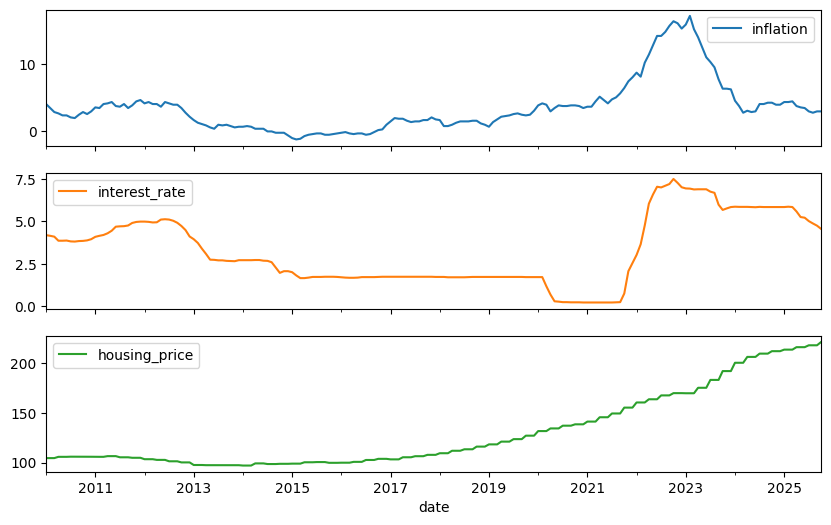

In [3]:
import matplotlib.pyplot as plt

df.plot(subplots=True, figsize=(10,6))
plt.show()

### Interpretation

The three variables clearly show how key parts of the economy are connected and influence each other over time.

- Inflation remained relatively stable in the early period (2010–2013), followed by a phase of very low or near-zero inflation between 2014 and 2016. From 2017 onwards, inflation gradually increased, reaching a significant peak around 2022–2023. This spike likely reflects macroeconomic shocks such as global inflationary pressures. After 2023, inflation declines, indicating stabilization.

- Interest rates show a decreasing trend from 2010 to 2020, reaching near-zero levels around 2020. This suggests an accommodative monetary policy. However, around 2021–2022, interest rates increase sharply, likely as a response to rising inflation. After 2023, interest rates gradually decrease again.

- Housing prices show a steady upward trend in the long run. This growth becomes even more noticeable during periods of low interest rates, such as between 2013 and 2020, when borrowing is cheaper and demand for housing is stronger.

- Overall the data indicates that lower interest rates tend to support rising housing prices,while higher interest rates are introduced to reduce inflationary pressures.

- These variables are strongly interconnected and influence one another over time. Because of this dynamic relationship using a VAR model is appropriate for analysing how they interact.

### Apply ADF Test

In [7]:

from statsmodels.tsa.stattools import adfuller
def adf_test(series, name):
    result = adfuller(series)
    print(f"ADF Test for {name}")
    print("ADF Statistic:", result[0])
    print("p-value:", result[1])
    print("--------------------------")

# Run for each variable
adf_test(df['inflation'], 'Inflation')
adf_test(df['interest_rate'], 'Interest Rate')
adf_test(df['housing_price'], 'Housing Price')

ADF Test for Inflation
ADF Statistic: -1.3736087539653816
p-value: 0.5948609967199552
--------------------------
ADF Test for Interest Rate
ADF Statistic: -2.577572538311631
p-value: 0.09772172452232347
--------------------------
ADF Test for Housing Price
ADF Statistic: 1.4978154352404223
p-value: 0.9975161958821439
--------------------------


### ADF Test Interpretation

- We applied the Augmented Dickey-Fuller (ADF) test to check whether the variables are stationary over time.
- The results show that all three variables — inflation, interest rate, and housing price — have p-values greater than 0.05.
- This means that the variables are not stationary, and their statistical properties (such as mean and variance) change over time.
- In simple terms, these variables follow trends and are influenced by long-term economic movements, which is common for macroeconomic data.
- Because the data is non-stationary, it is not suitable for time series modeling in its original form.
- Therefore, we apply differencing to remove trends and stabilize the data before building the VAR model.

### Data Transformation
To prepare the data for time series modeling, we apply first-order differencing to make the series stationary. This ensures that the statistical properties of the data remain consistent over time.


In [8]:
df_diff = df.diff().dropna()
df_diff.head()

,inflation,interest_rate,housing_price
date,,,
2010-02-01,-0.6,-0.04,0.00
2010-03-01,-0.6,-0.05,0.00
2010-04-01,-0.2,-0.24,1.27
2010-05-01,-0.3,0.00,0.00
2010-06-01,0.0,0.01,0.00


First-order differencing was applied to remove trends from the data and stabilize the series. The transformed values represent period-to-period changes, and the reduced fluctuations around zero indicate that the data is becoming more stationary.

### ADF Test again on the differenced data

In [9]:
adf_test(df_diff['inflation'], 'Inflation (diff)')
adf_test(df_diff['interest_rate'], 'Interest Rate (diff)')
adf_test(df_diff['housing_price'], 'Housing Price (diff)')

ADF Test for Inflation (diff)
ADF Statistic: -5.556353635921693
p-value: 1.5777051015893186e-06
--------------------------
ADF Test for Interest Rate (diff)
ADF Statistic: -4.220377990266577
p-value: 0.0006084757020080239
--------------------------
ADF Test for Housing Price (diff)
ADF Statistic: -2.488244167554678
p-value: 0.11836090994570542
--------------------------


### Interpretation After First Differencing
- After applying first-order differencing, we performed the ADF test again to check whether the data became stationary.

- The results show that inflation and interest rates now have p-values less than 0.05, which means these variables have become stationary after differencing. This indicates that differencing successfully removed trends and stabilized these two series.

- However, the housing price variable still has a p-value greater than 0.05, meaning it remains non-stationary even after the first transformation. This suggests that housing prices have a stronger trend component and require further transformation.

- Because not all variables are stationary yet, we apply an additional transformation (second-order differencing) to the housing price series before proceeding to the VAR model.

In [10]:
df_diff['housing_price_2diff'] = df_diff['housing_price'].diff()
df_diff = df_diff.dropna()


In [11]:
adf_test(df_diff['housing_price_2diff'], 'Housing Price (2nd diff)')


ADF Test for Housing Price (2nd diff)
ADF Statistic: -56.56541069225478
p-value: 0.0
--------------------------


### Interpretation After Second Differencing:
- After applying second-order differencing to the housing price variable, we performed the ADF test again to check for stationarity.
-The results show that the p-value is now very close to 0, which is much less than 0.05. This indicates that the housing price series has become stationary after the second transformation.
- In simple terms, this means that the trend and long-term movements in the housing price data have been successfully removed, and the data now fluctuates in a stable pattern over time.